In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
def LSTMNoDiff(channels=3):
    return LSTMPrediction(channels=channels, num_diff=False)

In [10]:
model = PDEInspiredModel(ts_model=LSTMNoDiff,model_channels=4)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.3397, 0.3667, 0.2936]], grad_fn=<SoftmaxBackward0>)

In [11]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 231

saving model

1.9500265985294973e-10
epoch 0, loss=1.5581534504890442, val. loss=1.456777572631836, val. acc.=0.1059730276465416, time: 149ms
3.4061628517711995e-10
epoch 1, loss=1.5288419127464294, val. loss=1.455156922340393, val. acc.=0.1059730276465416, time: 124ms
5.034916789048438e-10
epoch 2, loss=1.5262967944145203, val. loss=1.4576783180236816, val. acc.=0.1059730276465416, time: 118ms
1.6464295204965396e-10
epoch 3, loss=1.5426305532455444, val. loss=1.4585950374603271, val. acc.=0.1059730276465416, time: 124ms
2.817292510393088e-10
epoch 4, loss=1.547152578830719, val. loss=1.458759069442749, val. acc.=0.1059730276465416, time: 121ms
4.0551167979074876e-10
epoch 5, loss=1.5401378273963928, val. loss=1.4574607610702515, val. acc.=0.1059730276465416, time: 125ms
0.0
epoch 6, loss=1.5237377882003784, val. loss=1.4541174173355103, val. acc.=0.1059730276465416, time: 125ms
4.728293312439291e-09
epoch 7, loss=1.520683228969574, val. loss=1.443795919418335, va

3.241345984861255e-05
epoch 65, loss=0.49347245693206787, val. loss=0.46260687708854675, val. acc.=0.899807333946228, time: 129ms
0.00011849858674395364
epoch 66, loss=0.5097765475511551, val. loss=0.4924149513244629, val. acc.=0.8227360248565674, time: 138ms
2.3998418328119442e-05
epoch 67, loss=0.4809045344591141, val. loss=0.45609113574028015, val. acc.=0.8882466554641724, time: 137ms
1.6998936189338565e-05
epoch 68, loss=0.4447546750307083, val. loss=0.4584037661552429, val. acc.=0.8747591376304626, time: 167ms
1.0497529729036614e-05
epoch 69, loss=0.48504531383514404, val. loss=0.45418402552604675, val. acc.=0.8921002149581909, time: 131ms
0.00019159778821631335
epoch 70, loss=0.470734179019928, val. loss=0.46084633469581604, val. acc.=0.8651252388954163, time: 123ms
0.0
epoch 71, loss=0.46998946368694305, val. loss=0.454683393239975, val. acc.=0.8805394768714905, time: 129ms
3.0689894629176706e-05
epoch 72, loss=0.4566095918416977, val. loss=0.46185576915740967, val. acc.=0.86319

5.05521300624423e-05
epoch 129, loss=0.4664416164159775, val. loss=0.4492073655128479, val. acc.=0.8959537744522095, time: 138ms
0.00021207728423178196
epoch 130, loss=0.4818255752325058, val. loss=0.5081645846366882, val. acc.=0.8208092451095581, time: 134ms
0.00013930173736298457
epoch 131, loss=0.45698750019073486, val. loss=0.4546106159687042, val. acc.=0.9017341136932373, time: 137ms
5.57780858798651e-05
epoch 132, loss=0.47687990963459015, val. loss=0.4986311197280884, val. acc.=0.8323699235916138, time: 139ms
0.0001693501990303048
epoch 133, loss=0.4561324417591095, val. loss=0.45018261671066284, val. acc.=0.8786126971244812, time: 150ms
0.0
epoch 134, loss=0.49004776775836945, val. loss=0.45196399092674255, val. acc.=0.8786126971244812, time: 141ms
5.160943419468822e-05
epoch 135, loss=0.48284393548965454, val. loss=0.49115654826164246, val. acc.=0.8304431438446045, time: 155ms
5.243249506747816e-05
epoch 136, loss=0.46051938831806183, val. loss=0.45899105072021484, val. acc.=0

0.0003052704341826029
epoch 193, loss=0.4516337960958481, val. loss=0.44362810254096985, val. acc.=0.8921002149581909, time: 133ms
4.9314349780615885e-05
epoch 194, loss=0.47509559988975525, val. loss=0.4865376353263855, val. acc.=0.8439306616783142, time: 132ms
1.558822077640798e-05
epoch 195, loss=0.4538887292146683, val. loss=0.4437659680843353, val. acc.=0.8824662566184998, time: 135ms
0.0
epoch 196, loss=0.4628223180770874, val. loss=0.4688180387020111, val. acc.=0.849711000919342, time: 135ms
4.865330993197858e-05
epoch 197, loss=0.4249791204929352, val. loss=0.4437684118747711, val. acc.=0.8863198161125183, time: 137ms
3.60891644959338e-05
epoch 198, loss=0.4058272987604141, val. loss=0.4481571316719055, val. acc.=0.8747591376304626, time: 134ms
0.0003837323820334859
epoch 199, loss=0.43505287170410156, val. loss=0.45556265115737915, val. acc.=0.8593448996543884, time: 138ms
1.4006495803187136e-05
epoch 200, loss=0.4111459106206894, val. loss=0.4416485130786896, val. acc.=0.8824

4.7852819989202544e-05
epoch 257, loss=0.4512155205011368, val. loss=0.44043901562690735, val. acc.=0.8728323578834534, time: 136ms
6.446359748224495e-06
epoch 258, loss=0.47456830739974976, val. loss=0.43426549434661865, val. acc.=0.8959537744522095, time: 133ms
9.618177864467725e-05
epoch 259, loss=0.4454379081726074, val. loss=0.5292028188705444, val. acc.=0.7957611083984375, time: 142ms
2.171183587051928e-05
epoch 260, loss=0.4457182437181473, val. loss=0.43543267250061035, val. acc.=0.8978805541992188, time: 135ms
0.00032877258490771055
epoch 261, loss=0.46535852551460266, val. loss=0.44390296936035156, val. acc.=0.8670520186424255, time: 140ms
0.00017143548757303506
epoch 262, loss=0.4153567850589752, val. loss=0.4670106768608093, val. acc.=0.8516377806663513, time: 168ms
4.6232315071392804e-05
epoch 263, loss=0.43564023077487946, val. loss=0.433759868144989, val. acc.=0.8940269947052002, time: 161ms
5.391486774897203e-05
epoch 264, loss=0.43443553149700165, val. loss=0.455994546

...

0.19049856811761856
epoch 9690, loss=0.008298061089590192, val. loss=0.20601283013820648, val. acc.=0.9865125417709351, time: 146ms
0.13684524595737457
epoch 9691, loss=0.008445132989436388, val. loss=0.2016337662935257, val. acc.=0.9884393215179443, time: 148ms
0.0
epoch 9692, loss=0.00852061784826219, val. loss=0.1985088586807251, val. acc.=0.9884393215179443, time: 147ms
0.0
epoch 9693, loss=0.008723723702132702, val. loss=0.20211561024188995, val. acc.=0.9884393215179443, time: 147ms
0.0
epoch 9694, loss=0.009012831840664148, val. loss=0.1996951699256897, val. acc.=0.9884393215179443, time: 149ms
0.01629924697044771
epoch 9695, loss=0.008083062712103128, val. loss=0.19275222718715668, val. acc.=0.9884393215179443, time: 143ms
0.08737476170063019
epoch 9696, loss=0.008280572481453419, val. loss=0.18919645249843597, val. acc.=0.9884393215179443, time: 149ms
0.0
epoch 9697, loss=0.007412931881844997, val. loss=0.18766671419143677, val. acc.=0.9884393215179443, time: 148ms
0.0183158889

0.013438297435641289
epoch 9756, loss=0.007995336316525936, val. loss=0.19740214943885803, val. acc.=0.9884393215179443, time: 143ms
0.0
epoch 9757, loss=0.0073547185165807605, val. loss=0.20024585723876953, val. acc.=0.9884393215179443, time: 142ms
0.030064957216382027
epoch 9758, loss=0.0070817419327795506, val. loss=0.1985955536365509, val. acc.=0.9884393215179443, time: 148ms
0.0
epoch 9759, loss=0.006836939137428999, val. loss=0.19852665066719055, val. acc.=0.9865125417709351, time: 142ms
0.014552338048815727
epoch 9760, loss=0.006133583839982748, val. loss=0.19375160336494446, val. acc.=0.9884393215179443, time: 141ms
0.015046672895550728
epoch 9761, loss=0.007474655285477638, val. loss=0.18574726581573486, val. acc.=0.9884393215179443, time: 138ms
0.0
epoch 9762, loss=0.008476476417854428, val. loss=0.189081609249115, val. acc.=0.9884393215179443, time: 140ms
0.02649535797536373
epoch 9763, loss=0.005121195921674371, val. loss=0.19496451318264008, val. acc.=0.9884393215179443, t

0.0
epoch 9822, loss=0.012725461972877383, val. loss=0.19654139876365662, val. acc.=0.9845857620239258, time: 149ms
0.010084397159516811
epoch 9823, loss=0.04313045972958207, val. loss=0.21807697415351868, val. acc.=0.9768785834312439, time: 140ms
0.0
epoch 9824, loss=0.0466213533654809, val. loss=0.20572529733181, val. acc.=0.9614643454551697, time: 148ms
0.014849263243377209
epoch 9825, loss=0.05824782745912671, val. loss=0.23221160471439362, val. acc.=0.9576107859611511, time: 147ms
0.009548412432195619
epoch 9826, loss=0.0647781454026699, val. loss=0.1402609795331955, val. acc.=0.9865125417709351, time: 148ms
0.0
epoch 9827, loss=0.039854709059000015, val. loss=0.15190784633159637, val. acc.=0.9826589822769165, time: 140ms
0.010266312398016453
epoch 9828, loss=0.0396640170365572, val. loss=0.13437125086784363, val. acc.=0.9922928810119629, time: 148ms
0.024504555389285088
epoch 9829, loss=0.03176317922770977, val. loss=0.14861787855625153, val. acc.=0.9865125417709351, time: 147ms


0.016252094879746437
epoch 9888, loss=0.006972403964027762, val. loss=0.20126841962337494, val. acc.=0.9884393215179443, time: 148ms
0.0
epoch 9889, loss=0.00791065744124353, val. loss=0.19974179565906525, val. acc.=0.9884393215179443, time: 141ms
0.0
epoch 9890, loss=0.008460282813757658, val. loss=0.20622821152210236, val. acc.=0.9884393215179443, time: 141ms
0.014014728367328644
epoch 9891, loss=0.007518681930378079, val. loss=0.2091694474220276, val. acc.=0.9884393215179443, time: 144ms
0.11057280004024506
epoch 9892, loss=0.009223146364092827, val. loss=0.19503477215766907, val. acc.=0.9884393215179443, time: 146ms
0.0
epoch 9893, loss=0.008231176296249032, val. loss=0.1855383664369583, val. acc.=0.9903661012649536, time: 140ms
0.06820131838321686
epoch 9894, loss=0.008140826830640435, val. loss=0.20890390872955322, val. acc.=0.9865125417709351, time: 141ms
0.08383691497147083
epoch 9895, loss=0.009050771594047546, val. loss=0.21484418213367462, val. acc.=0.9865125417709351, time:

0.059544384479522705
epoch 9952, loss=0.008259416907094419, val. loss=0.20658795535564423, val. acc.=0.9845857620239258, time: 161ms
0.02913615945726633
epoch 9953, loss=0.007936354959383607, val. loss=0.19673165678977966, val. acc.=0.9884393215179443, time: 164ms
0.0
epoch 9954, loss=0.004458087380044162, val. loss=0.19562558829784393, val. acc.=0.9884393215179443, time: 147ms
0.010409459471702576
epoch 9955, loss=0.0050643079448491335, val. loss=0.20103947818279266, val. acc.=0.9884393215179443, time: 147ms
0.0
epoch 9956, loss=0.006121059530414641, val. loss=0.20466840267181396, val. acc.=0.9884393215179443, time: 148ms
0.026856040582060814
epoch 9957, loss=0.004810851416550577, val. loss=0.20202118158340454, val. acc.=0.9884393215179443, time: 143ms
0.13522590696811676
epoch 9958, loss=0.00763774081133306, val. loss=0.2000042051076889, val. acc.=0.9884393215179443, time: 144ms
0.007586271967738867
epoch 9959, loss=0.005731745506636798, val. loss=0.20237867534160614, val. acc.=0.988

In [12]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

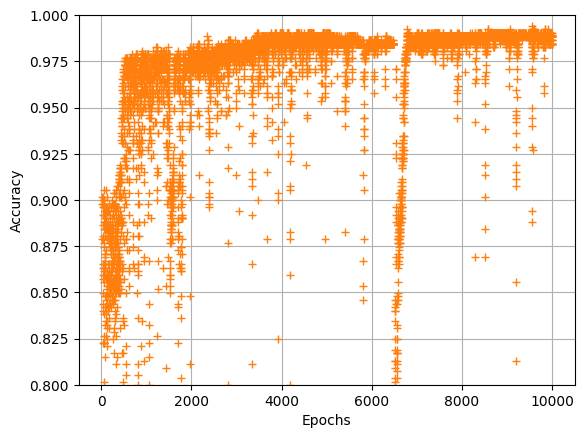

In [13]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

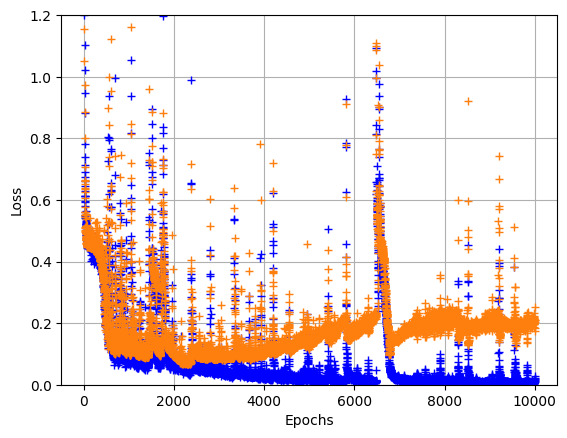

In [14]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [15]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [16]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [17]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9776
Explained variance score: 0.9777
Mean squared error: 0.0039
Accuracy Score: 0.9942
Precision: [0.9888 0.9954 0.9987]
Recall: [0.9986 0.9729 0.9962]
Precision macro: 0.994318829282525
Recall macro: 0.9892276098441886


### Train quality

In [18]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[709.,   1.,   0.],
       [  5., 215.,   1.],
       [  3.,   0., 795.]])

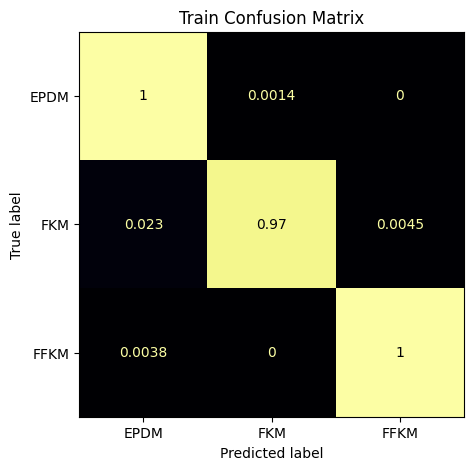

In [19]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

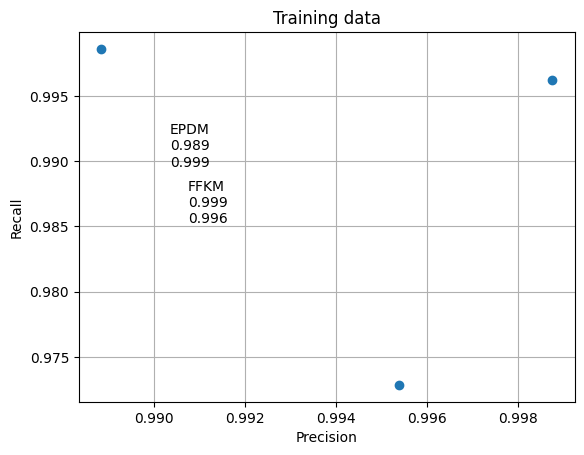

In [20]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [21]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.9999988e-01, 6.7898031e-12, 1.2691001e-07],
       [9.9980050e-01, 1.9469076e-04, 4.7774379e-06],
       [3.1935278e-13, 2.5074573e-12, 1.0000000e+00],
       ...,
       [9.7585277e-14, 2.1865709e-09, 1.0000000e+00],
       [1.7466691e-06, 9.9999821e-01, 5.6350963e-10],
       [8.2943291e-11, 1.0163690e-09, 1.0000000e+00]], dtype=float32)

### Test metrics

In [22]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [23]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9776
Explained variance score: 0.9777
Mean squared error: 0.0039
Accuracy Score: 0.9908
Precision: [1.0000 0.9184 1.0000]
Recall: [0.9832 1.0000 0.9952]
Precision macro: 0.9727891156462585
Recall macro: 0.9928185114894905


### Test quality

In [24]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[176.,   3.,   0.],
       [  0.,  45.,   0.],
       [  0.,   1., 208.]])

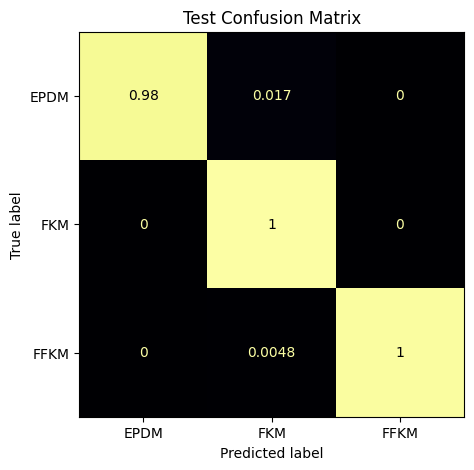

In [25]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

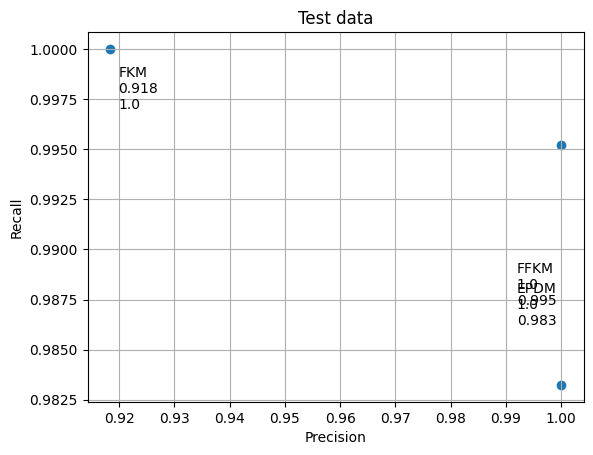

In [26]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
torch.save(deepcopy(model.state_dict()), 'LSTMModel_nodiff.pt')